In [ ]:
!pip install ucimlrepo

## dibites from cdc

In [ ]:
import pandas as pd
import numpy as np
import os
import json
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:

#this section from cdc website on how to import there data

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
x = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
#print(cdc_diabetes_health_indicators.metadata)

# variable information
#print(cdc_diabetes_health_indicators.variables)


In [ ]:
cdc_diabetes_health_indicators.metadata

{'uci_id': 891,
 'name': 'CDC Diabetes Health Indicators',
 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators',
 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv',
 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ',
 'area': 'Health and Medicine',
 'tasks': ['Classification'],
 'characteristics': ['Tabular', 'Multivariate'],
 'num_instances': 253680,
 'num_features': 21,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Sex', 'Age', 'Education Level', 'Income'],
 'target_col': ['Diabetes_binary'],
 'index_col': ['ID'],
 'has_missing_values': 'no',
 'missing_values_symbol

In [ ]:
cdc_diabetes_health_indicators.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,Patient ID,None,no
1,Diabetes_binary,Target,Binary,None,0 = no diabetes 1 = prediabetes or diabetes,None,no
2,HighBP,Feature,Binary,None,0 = no high BP 1 = high BP,None,no
3,HighChol,Feature,Binary,None,0 = no high cholesterol 1 = high cholesterol,None,no
4,CholCheck,Feature,Binary,None,0 = no cholesterol check in 5 years 1 = yes ch...,None,no
5,BMI,Feature,Integer,None,Body Mass Index,None,no
6,Smoker,Feature,Binary,None,Have you smoked at least 100 cigarettes in you...,None,no
7,Stroke,Feature,Binary,None,(Ever told) you had a stroke. 0 = no 1 = yes,None,no
8,HeartDiseaseorAttack,Feature,Binary,None,coronary heart disease (CHD) or myocardial inf...,None,no
9,PhysActivity,Feature,Binary,None,physical activity in past 30 days - not includ...,None,no


In [ ]:
# Combine features (X) and target (y) into one DataFrame
df = pd.concat([x, y], axis=1)


In [ ]:
df.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

In [ ]:
df.isnull().sum()

,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0
Veggies,0


no missing data

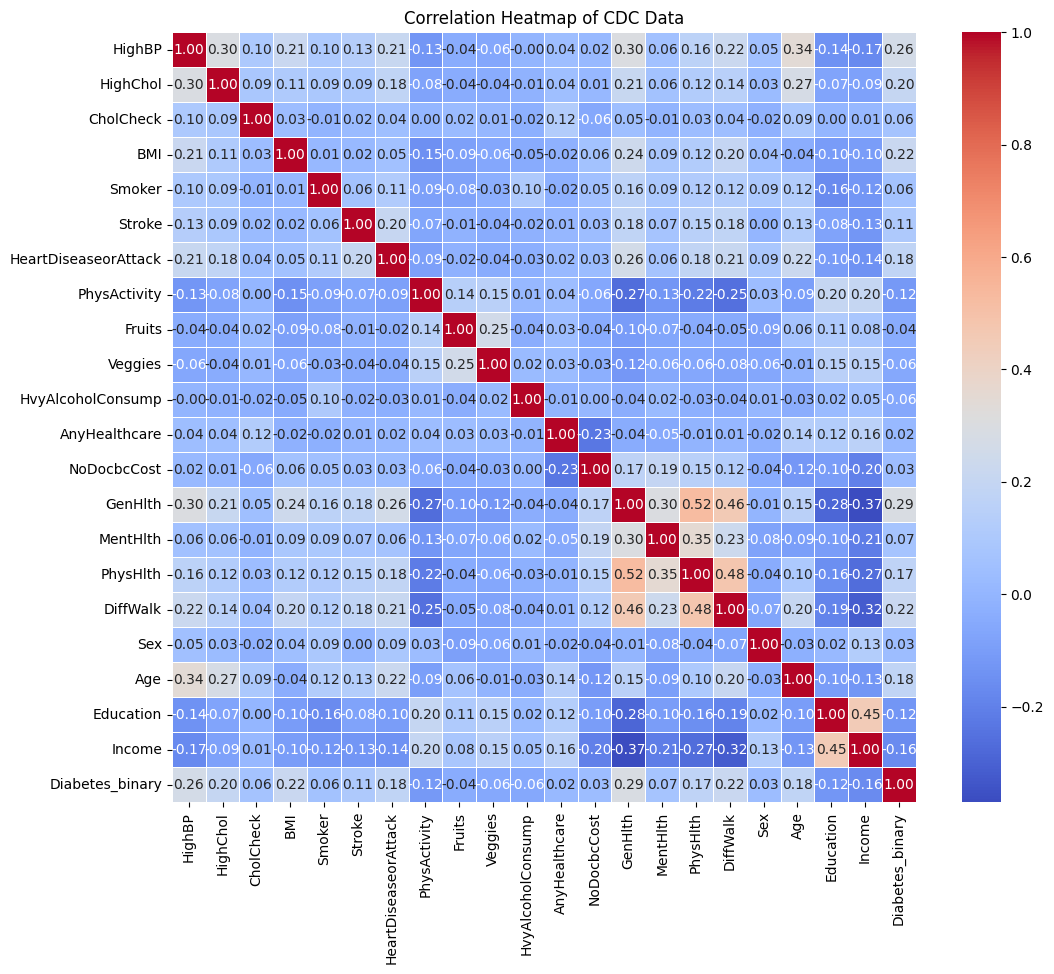

In [ ]:

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of CDC Data')
plt.show()


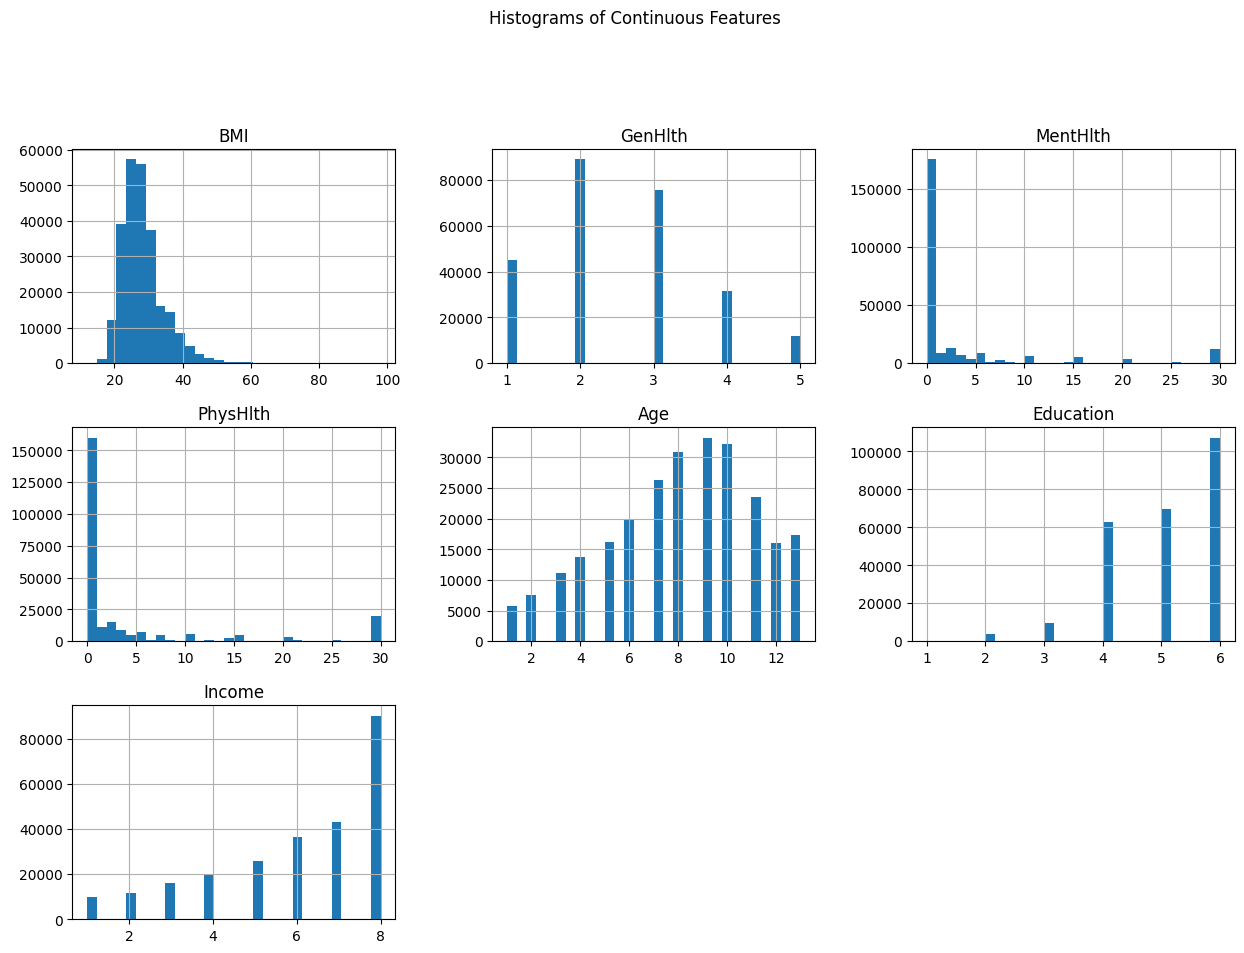

In [ ]:
continuous_cols = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

df[continuous_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of Continuous Features", y=1.02)
plt.show()


these grafe show the demografic and the tells us abou the people , they are in higher bracket mostly , with good physical healtha nd meantal health, in midle ages
and had desent educaytion but the data is of 23k people taht means there ware enghof entrys in each sub collam

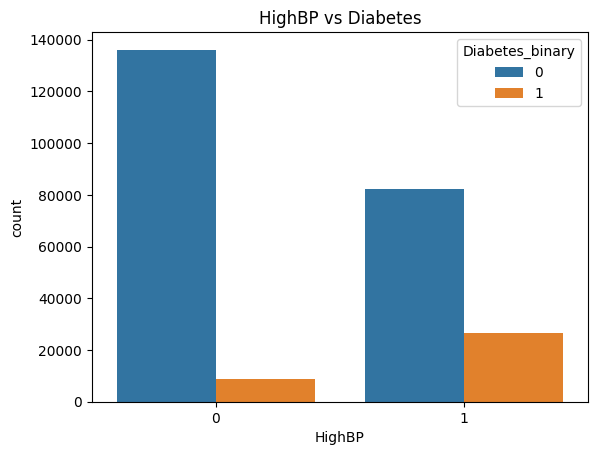

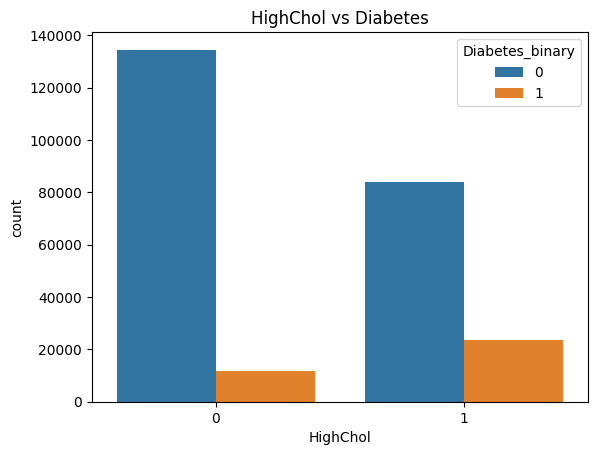

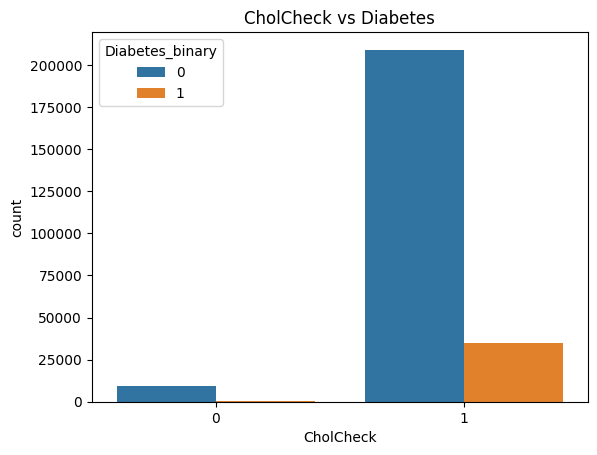

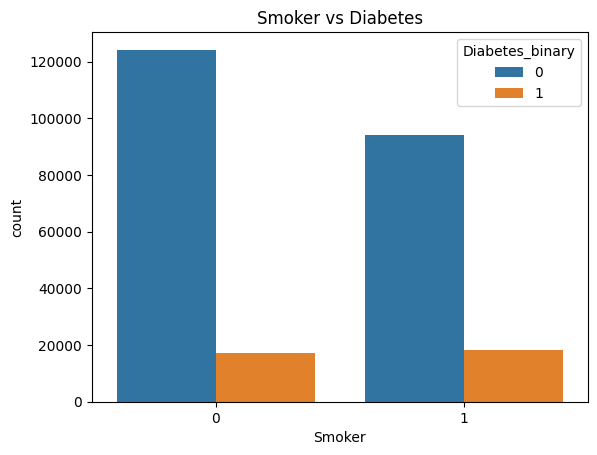

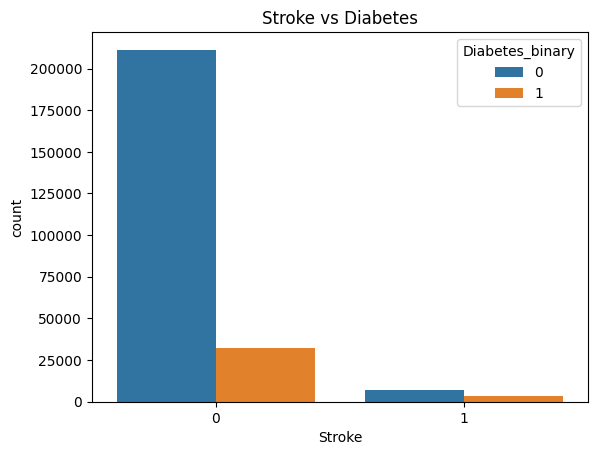

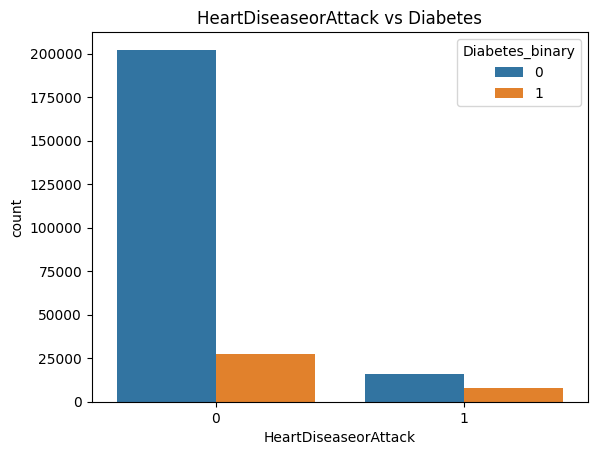

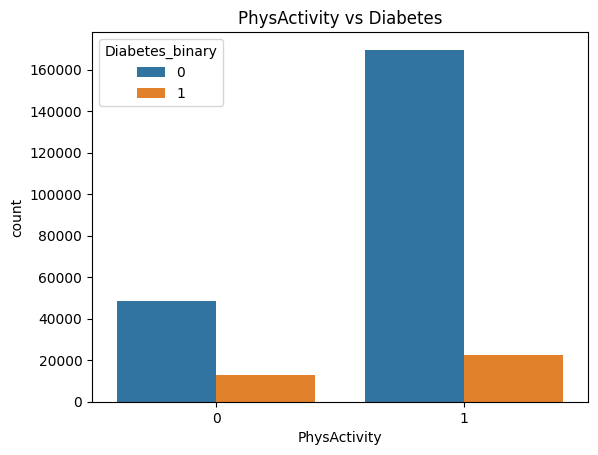

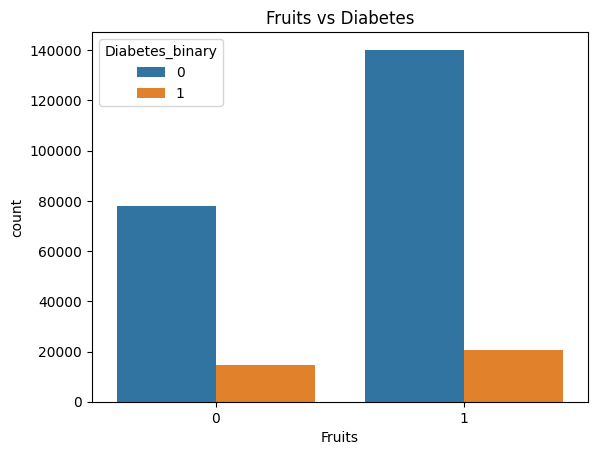

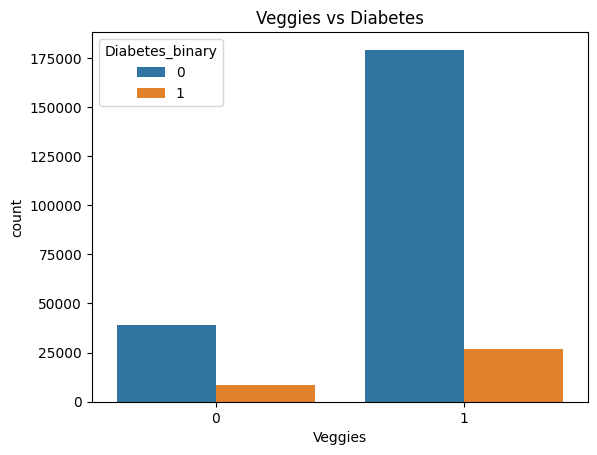

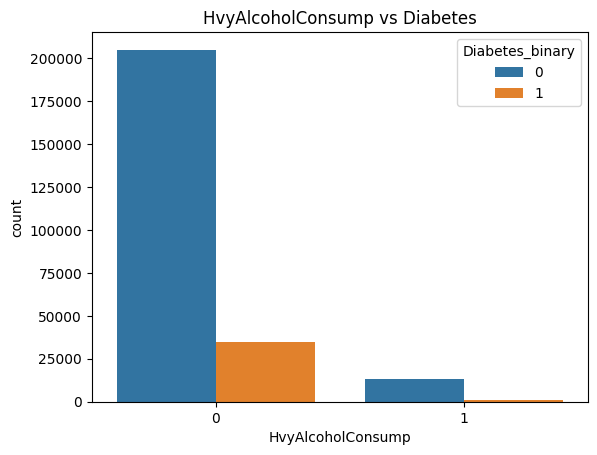

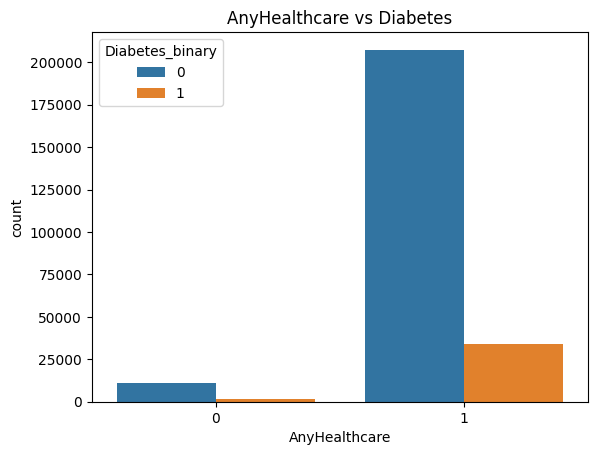

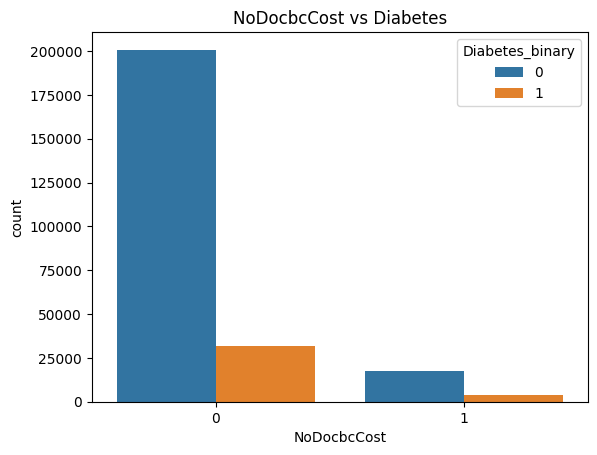

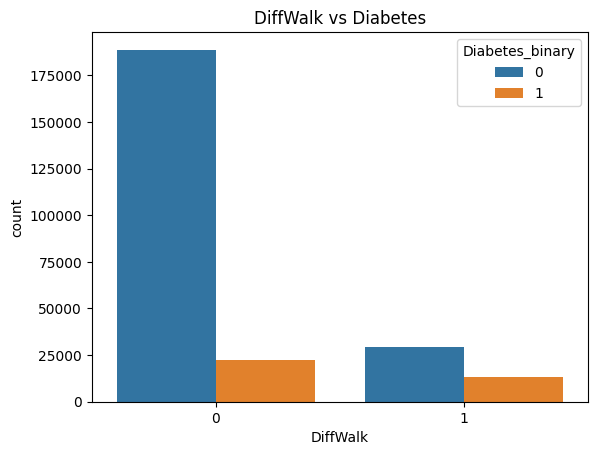

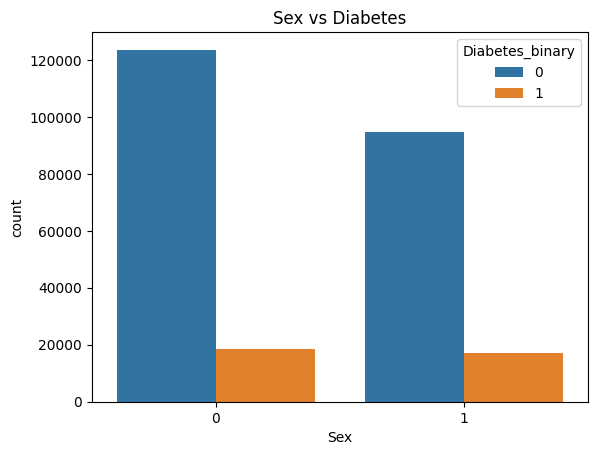

In [ ]:

binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
               'DiffWalk', 'Sex']

for col in binary_cols:



    sns.countplot(data=df, x=col, hue='Diabetes_binary')
    plt.title(f'{col} vs Diabetes')
    plt.show()



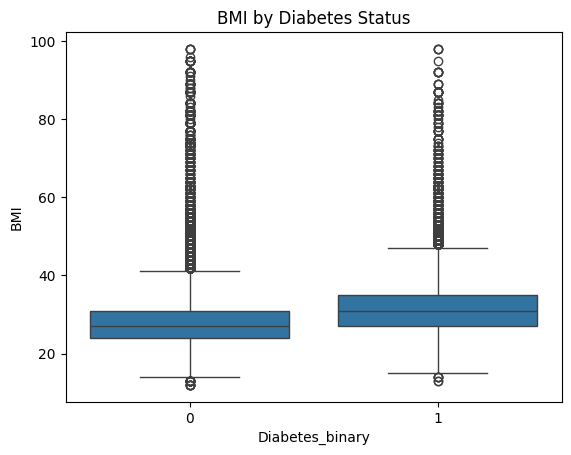

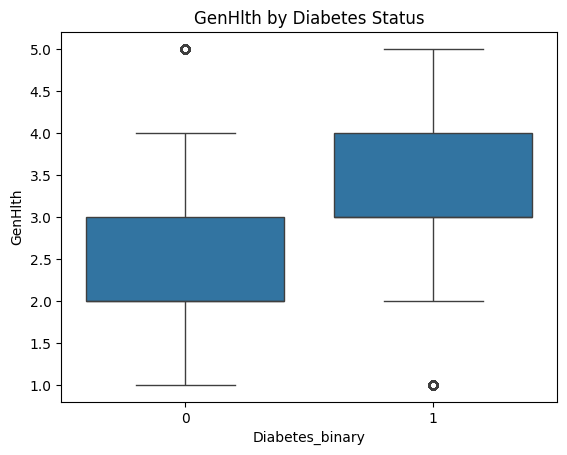

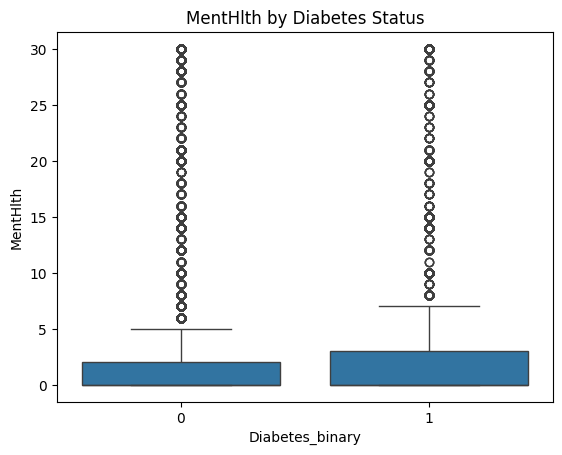

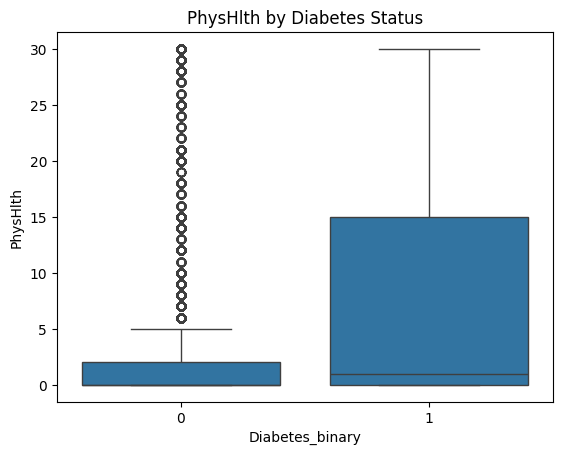

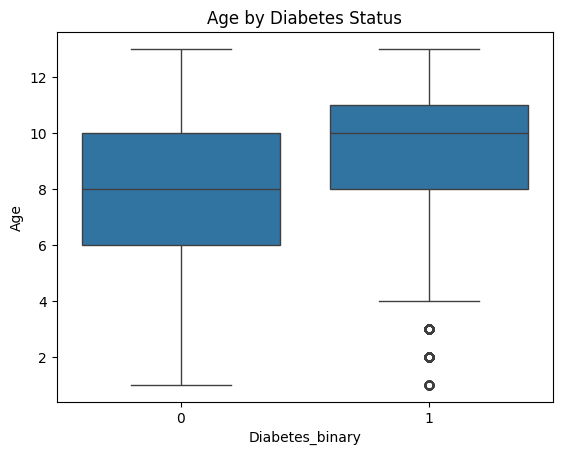

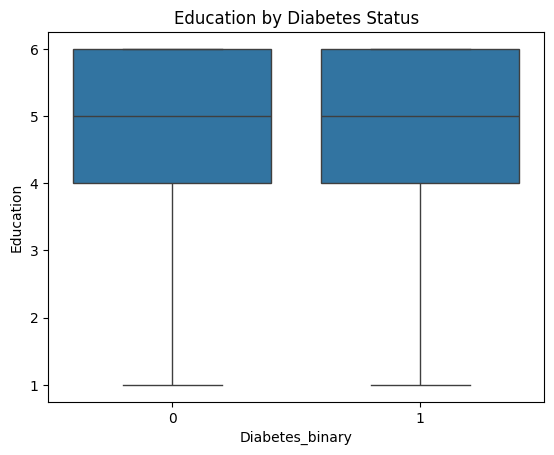

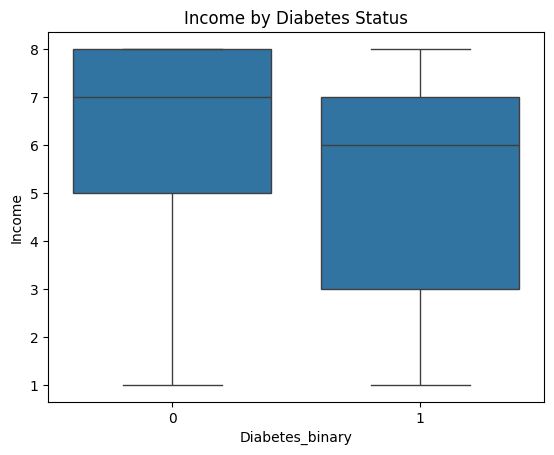

In [ ]:
for col in continuous_cols:
    sns.boxplot(x='Diabetes_binary', y=col, data=df)
    plt.title(f'{col} by Diabetes Status')
    plt.show()


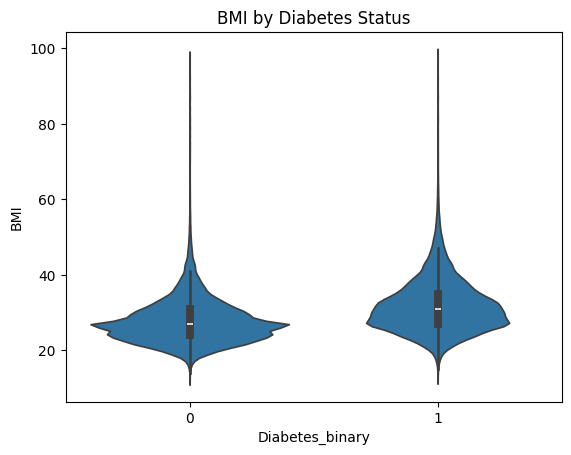

In [ ]:
sns.violinplot(x='Diabetes_binary', y='BMI', data=df)
plt.title('BMI by Diabetes Status')
plt.show()


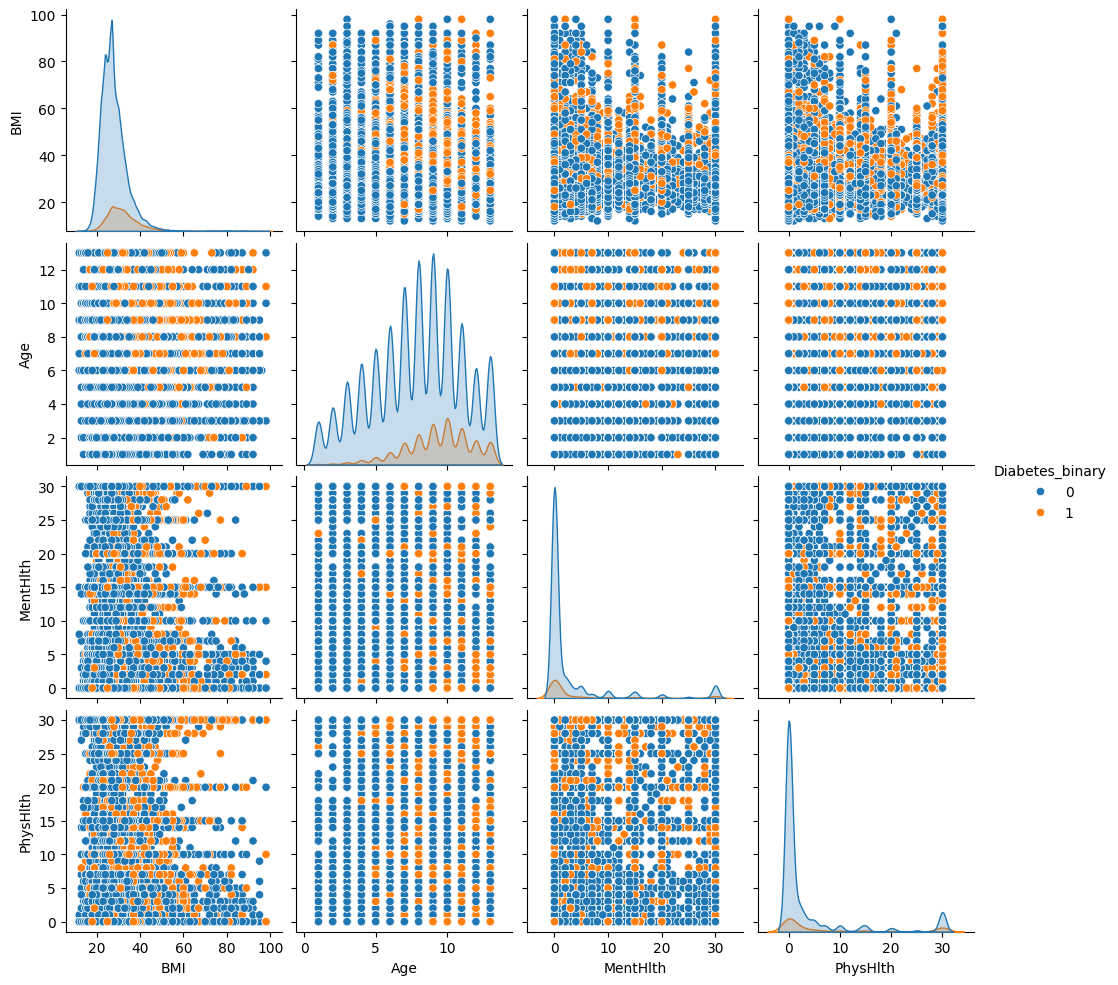

In [ ]:
selected_cols = ['BMI', 'Age',  'MentHlth', 'PhysHlth', 'Diabetes_binary']
sns.pairplot(df[selected_cols], hue='Diabetes_binary')
plt.show()


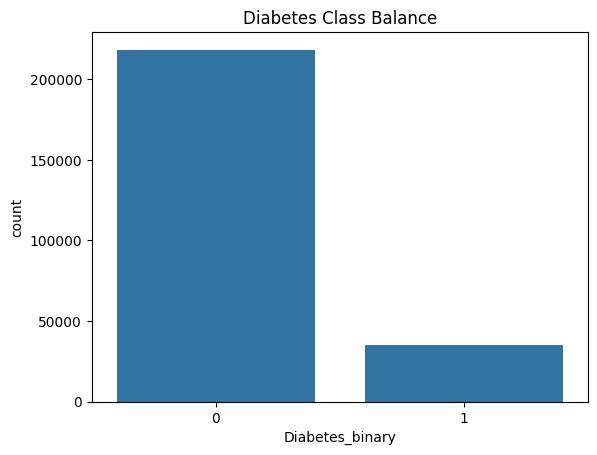

In [ ]:
sns.countplot(x='Diabetes_binary', data=df)
plt.title("Diabetes Class Balance")
plt.show()


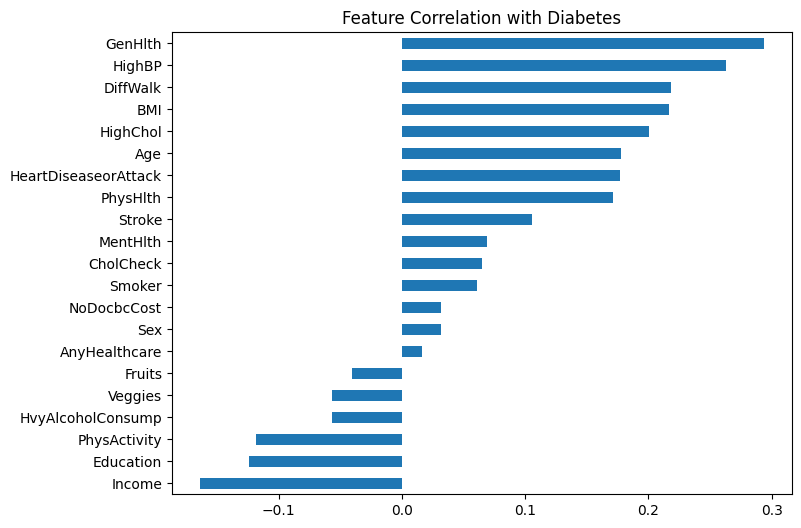

In [ ]:
correlations = df.corr()['Diabetes_binary'].drop('Diabetes_binary')
correlations.sort_values().plot(kind='barh', figsize=(8, 6), title='Feature Correlation with Diabetes')
plt.show()


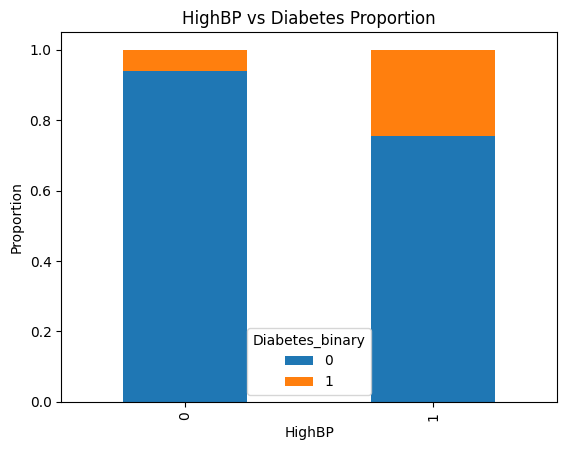

In [ ]:
pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='index').plot(kind='bar', stacked=True)
plt.title("HighBP vs Diabetes Proportion")
plt.ylabel("Proportion")
plt.show()


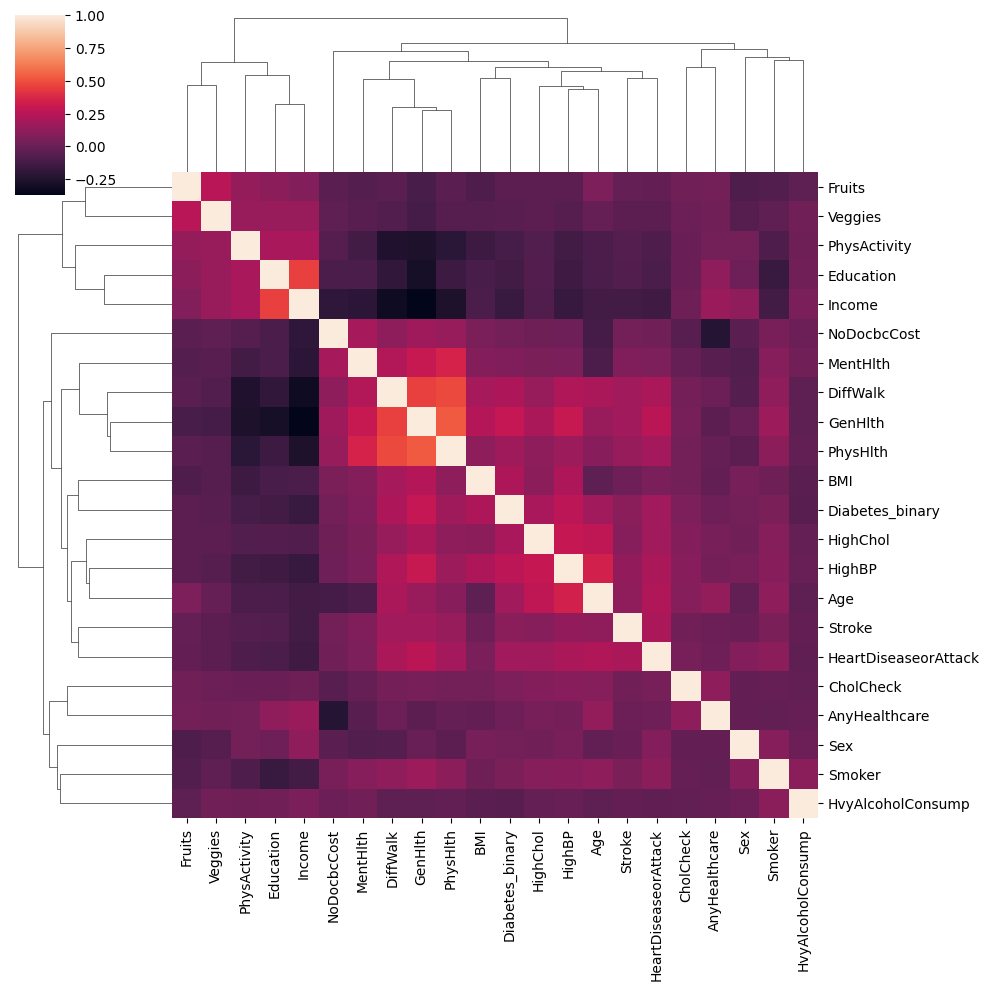

In [ ]:
sns.clustermap(df.corr())
plt.show()

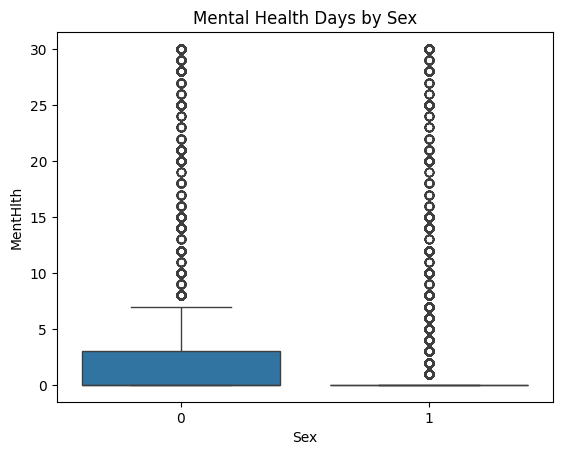

,MentHlth
Sex,
0,3.715434
1,2.510322


In [ ]:
sns.boxplot(x='Sex', y='MentHlth', data=df)
plt.title('Mental Health Days by Sex')
plt.show()

df.groupby('Sex')['MentHlth'].mean()


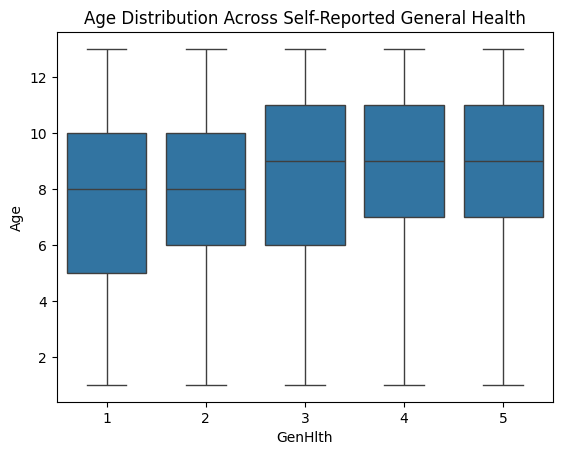

In [ ]:
sns.boxplot(x='GenHlth', y='Age', data=df)
plt.title('Age Distribution Across Self-Reported General Health')
plt.show()


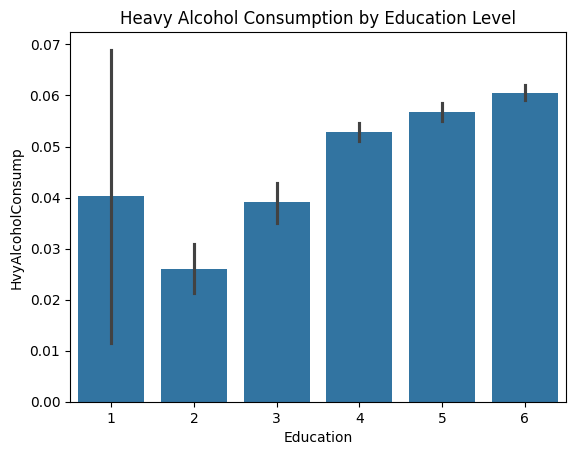

In [ ]:
sns.barplot(x='Education', y='HvyAlcoholConsump', data=df)
plt.title('Heavy Alcohol Consumption by Education Level')
plt.show()


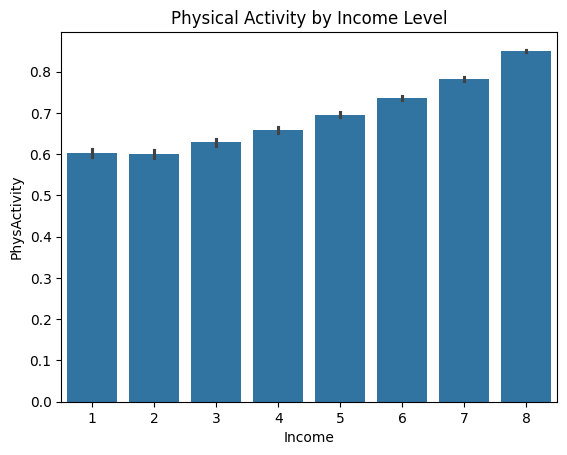

In [ ]:
sns.barplot(x='Income', y='PhysActivity', data=df)
plt.title('Physical Activity by Income Level')
plt.show()


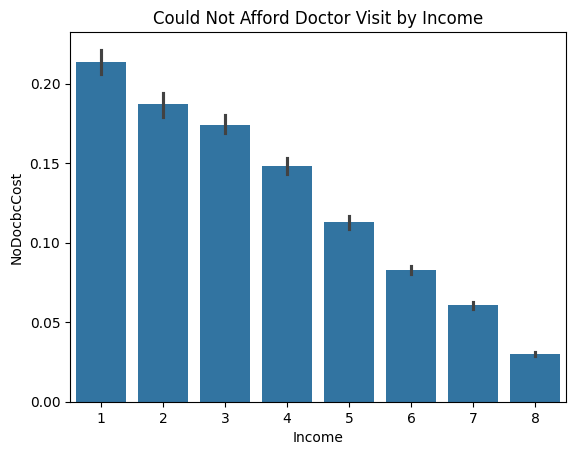

In [ ]:
sns.barplot(x='Income', y='NoDocbcCost', data=df)
plt.title('Could Not Afford Doctor Visit by Income')
plt.show()


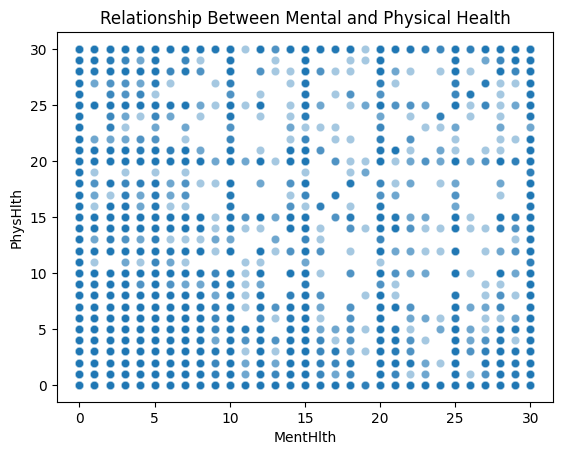

In [ ]:
sns.scatterplot(x='MentHlth', y='PhysHlth', data=df, alpha=0.4)
plt.title('Relationship Between Mental and Physical Health')
plt.show()


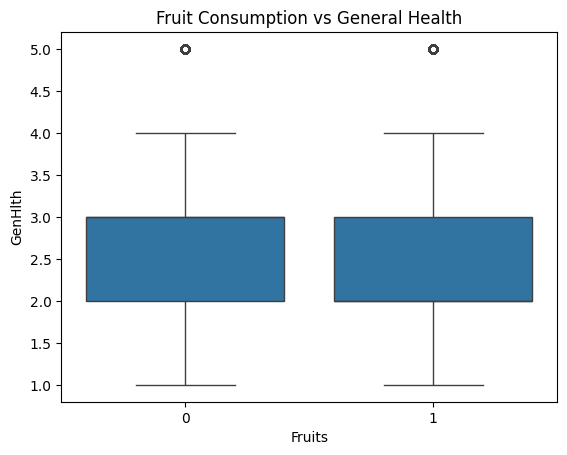

In [ ]:
sns.boxplot(x='Fruits', y='GenHlth', data=df)
plt.title('Fruit Consumption vs General Health')
plt.show()


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
results = []


In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n▶️ Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Results Summary
    print(classification_report(y_test, y_pred))
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"AUC Score: {roc_auc:.3f}")
    print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    return {
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc,
        "CV Accuracy Mean": cv_scores.mean(),
        "CV Accuracy Std": cv_scores.std()
    }


In [ ]:


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best AUC Score:", grid.best_score_)


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Best AUC Score: 0.8246993691070225



▶️ Training: Logistic Regression


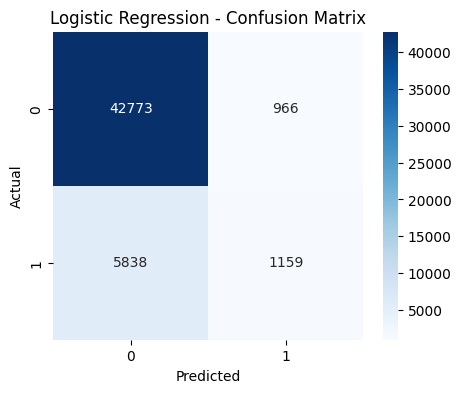

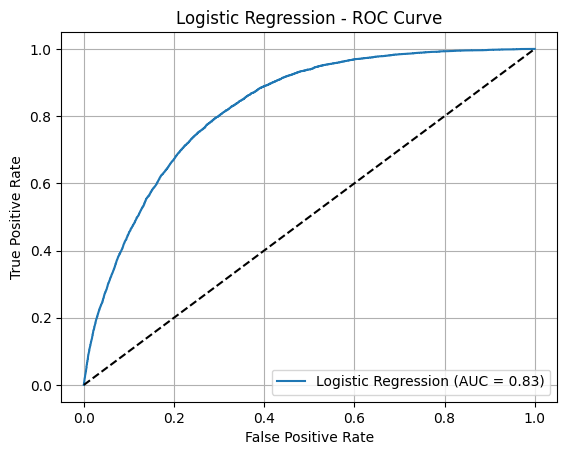

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43739
           1       0.55      0.17      0.25      6997

    accuracy                           0.87     50736
   macro avg       0.71      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736

Test Accuracy: 0.866
AUC Score: 0.826
CV Accuracy: 0.863 ± 0.000


In [ ]:
results.append(evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test))



▶️ Training: Random Forest


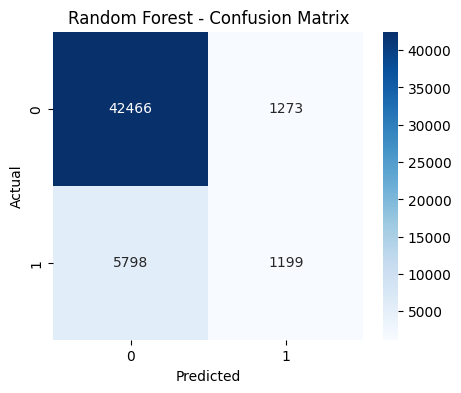

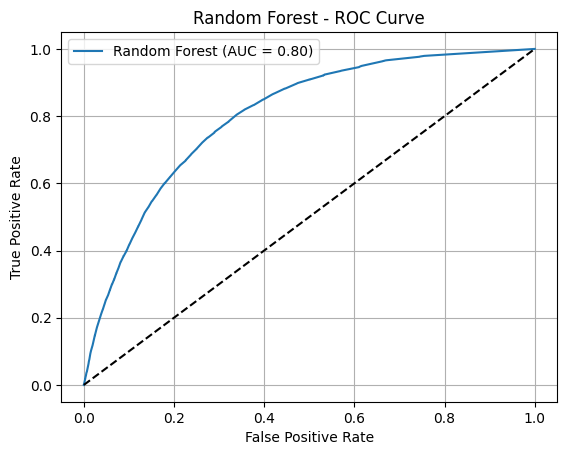

              precision    recall  f1-score   support

           0       0.88      0.97      0.92     43739
           1       0.49      0.17      0.25      6997

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.83      0.86      0.83     50736

Test Accuracy: 0.861
AUC Score: 0.802
CV Accuracy: 0.860 ± 0.001


In [ ]:
results.append(evaluate_model("Random Forest", RandomForestClassifier(), X_train, y_train, X_test, y_test))




▶️ Training: XGBoost


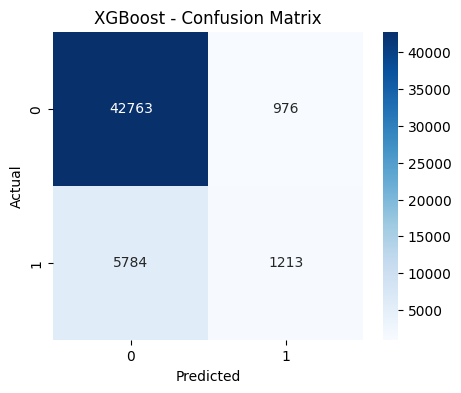

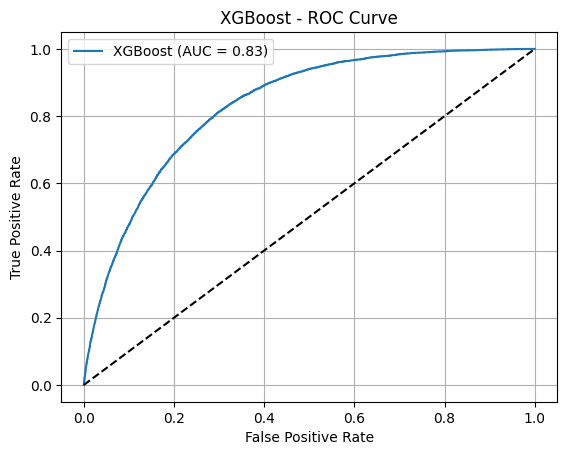

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43739
           1       0.55      0.17      0.26      6997

    accuracy                           0.87     50736
   macro avg       0.72      0.58      0.60     50736
weighted avg       0.84      0.87      0.84     50736

Test Accuracy: 0.867
AUC Score: 0.832
CV Accuracy: 0.865 ± 0.001


In [ ]:
results.append(evaluate_model("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), X_train, y_train, X_test, y_test))



▶️ Training: KNN


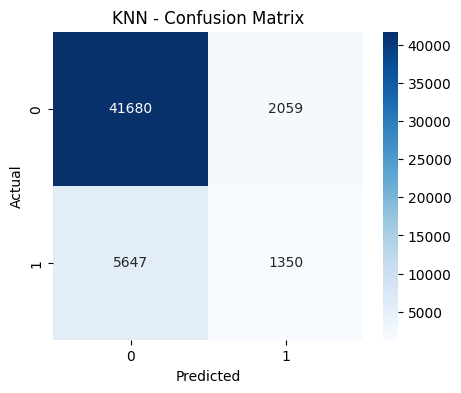

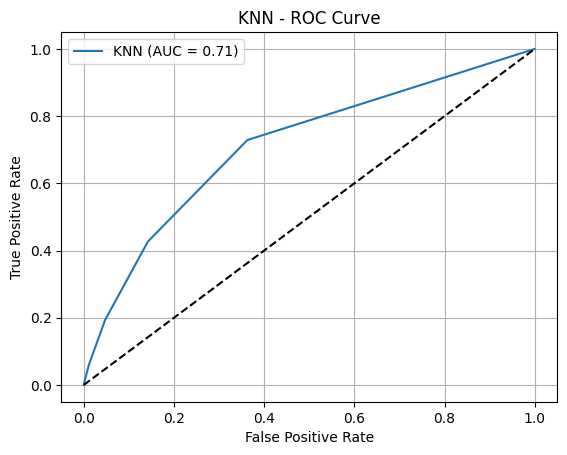

              precision    recall  f1-score   support

           0       0.88      0.95      0.92     43739
           1       0.40      0.19      0.26      6997

    accuracy                           0.85     50736
   macro avg       0.64      0.57      0.59     50736
weighted avg       0.81      0.85      0.82     50736

Test Accuracy: 0.848
AUC Score: 0.713
CV Accuracy: 0.847 ± 0.001


In [ ]:
results.append(evaluate_model("KNN", KNeighborsClassifier(n_neighbors=5,algorithm='auto',n_jobs=-1 ), X_train, y_train, X_test, y_test))




▶️ Training: MLP


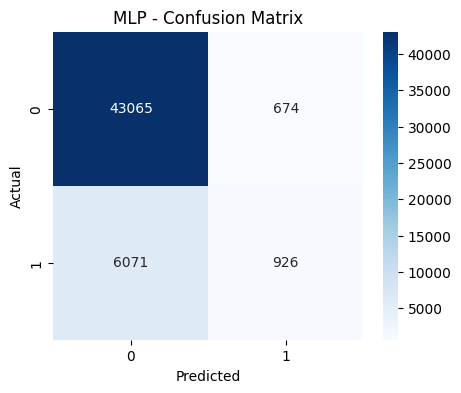

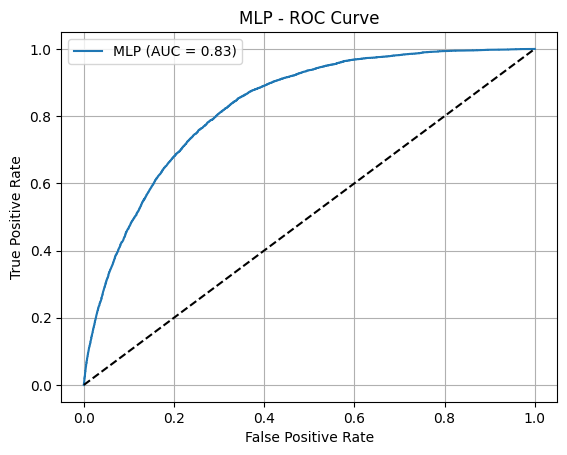

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43739
           1       0.58      0.13      0.22      6997

    accuracy                           0.87     50736
   macro avg       0.73      0.56      0.57     50736
weighted avg       0.84      0.87      0.83     50736

Test Accuracy: 0.867
AUC Score: 0.830
CV Accuracy: 0.865 ± 0.000


In [ ]:
results.append(evaluate_model("MLP", MLPClassifier(hidden_layer_sizes=(100,), early_stopping=True, max_iter=1000), X_train, y_train, X_test, y_test))


                 Model  Test Accuracy       AUC  CV Accuracy Mean  \
0  Logistic Regression       0.865894  0.826367          0.862947   
1        Random Forest       0.860632  0.801939          0.859562   
2              XGBoost       0.866761  0.832147          0.864509   
3                  KNN       0.848116  0.712661          0.847342   
4                  MLP       0.867057  0.829978          0.865199   

   CV Accuracy Std  
0         0.000394  
1         0.000640  
2         0.000803  
3         0.000583  
4         0.000489  


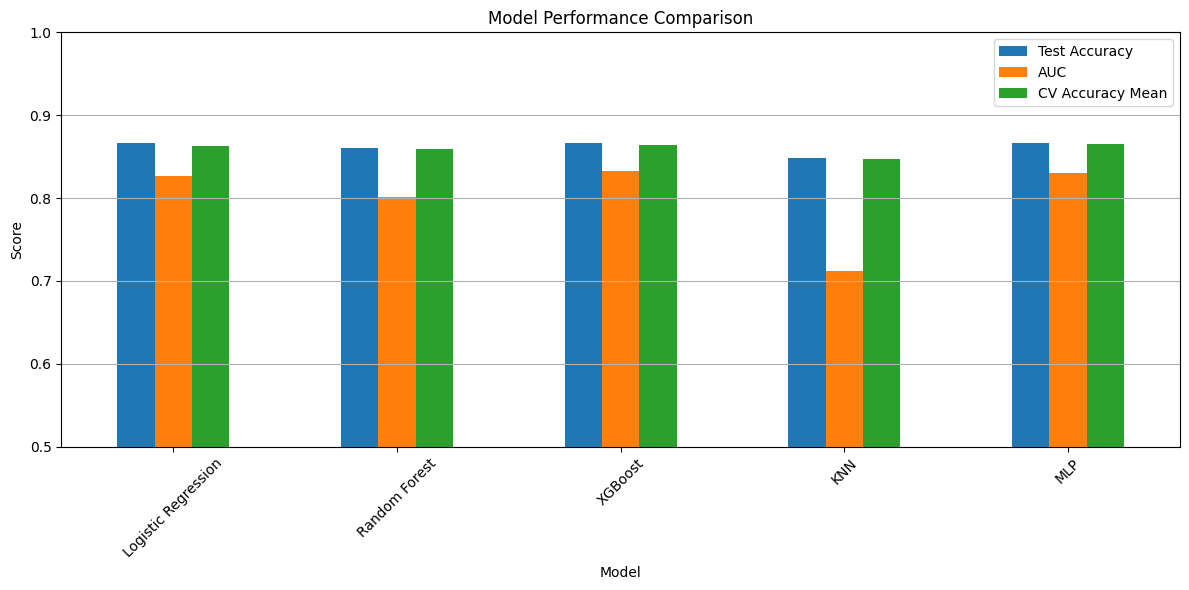

In [ ]:
results_df = pd.DataFrame(results)
print(results_df)

# Bar Plot of AUC and Accuracy
results_df.set_index("Model")[["Test Accuracy", "AUC", "CV Accuracy Mean"]].plot(kind="bar", figsize=(12,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
def plot_feature_importance(model, X_train, top_n=10):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:][::-1]
    features = X_train.columns[indices]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances[indices], y=features)
    plt.title("Top Feature Importances")
    plt.xlabel("Importance")
    plt.show()


In [ ]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="AUC", ascending=False)  # or 'Test Accuracy'
display(results_df)


,Model,Test Accuracy,AUC,CV Accuracy Mean,CV Accuracy Std
2,XGBoost,0.866761,0.832147,0.864509,0.000803
4,MLP,0.867057,0.829978,0.865199,0.000489
0,Logistic Regression,0.865894,0.826367,0.862947,0.000394
1,Random Forest,0.860632,0.801939,0.859562,0.000640
3,KNN,0.848116,0.712661,0.847342,0.000583


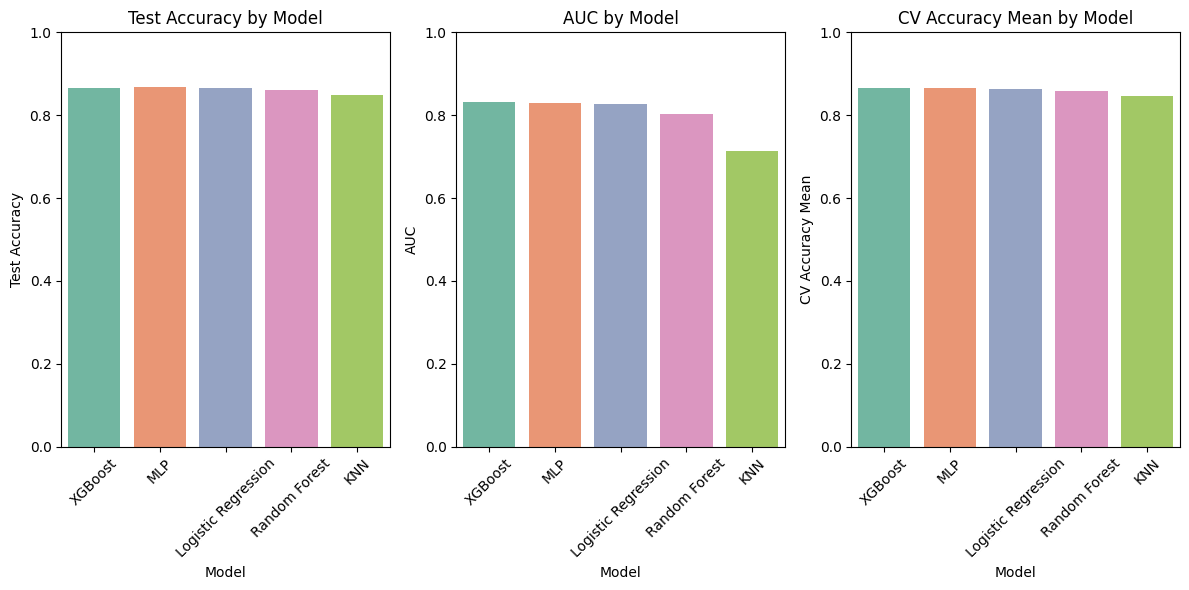

In [ ]:

metrics = ["Test Accuracy", "AUC", "CV Accuracy Mean"]

plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    sns.barplot(data=results_df, x="Model", y=metric, palette="Set2")
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()


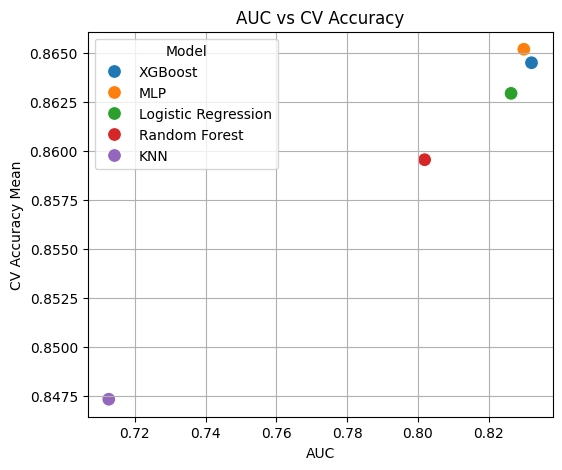

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=results_df, x="AUC", y="CV Accuracy Mean", hue="Model", s=100)
plt.title("AUC vs CV Accuracy")
plt.grid(True)
plt.show()


In [ ]:
print("🔝 Best by AUC:", results_df.loc[results_df['AUC'].idxmax(), 'Model'])
print("🔝 Best by Test Accuracy:", results_df.loc[results_df['Test Accuracy'].idxmax(), 'Model'])
print("🔝 Most stable CV:", results_df.loc[results_df['CV Accuracy Std'].idxmin(), 'Model'])


🔝 Best by AUC: XGBoost
🔝 Best by Test Accuracy: MLP
🔝 Most stable CV: Logistic Regression


In [ ]:
results_df.style.background_gradient(subset=["AUC", "Test Accuracy", "CV Accuracy Mean"], cmap="Greens")


,Model,Test Accuracy,AUC,CV Accuracy Mean,CV Accuracy Std
2,XGBoost,0.866761,0.832147,0.864509,0.000803
4,MLP,0.867057,0.829978,0.865199,0.000489
0,Logistic Regression,0.865894,0.826367,0.862947,0.000394
1,Random Forest,0.860632,0.801939,0.859562,0.000640
3,KNN,0.848116,0.712661,0.847342,0.000583
